# Fig5_nichespace_clustering.ipynb

This notebook demonstrates clustering of species niche spaces, drawing dendrograms, visualizing average niche spaces, and performing related calculations and plots.

In [1]:
from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail
import yaml
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.decomposition import PCA
import math
import feather
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, set_link_color_palette
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib as mpl
from scipy.stats import skewnorm
import matplotlib.ticker as mtick
from matplotlib.ticker import ScalarFormatter

# Set default matplotlib parameters.
set_mpl_defaults()

### Translate species name to Chinese

In [2]:
def get_chinese_sciname(target_name):
    change_names = {
    'Anas_zonorhyncha': 'Anas_poecilorhyncha', 
    'Cyanoderma_ruficeps': 'Stachyridopsis_ruficeps', 
    'Erythrogenys_erythrocnemis': 'Pomatorhinus_erythrocnemis', 
    'Ictinaetus_malaiensis': 'Ictinaetus_malayensis', 
    'Lewinia_striata': 'Gallirallus_striatus', 
    'Machlolophus_holsti': 'Parus_holsti', 
    'Pterorhinus_poecilorhynchus': 'Garrulax_poecilorhynchus', 
    'Pterorhinus_ruficeps': 'Garrulax_ruficeps', 
    'Schoeniparus_brunneus': 'Alcippe_brunnea', 
    'Sittiparus_castaneoventris': 'Poecile_varius', 
    'Synoicus_chinensis': 'Coturnix_chinensis', 
    'Taenioptynx_brodiei': 'Glaucidium_brodiei', 
    'Tarsiger_formosanus': 'Tarsiger_indicus', 
    'Turdus_niveiceps': 'Turdus_poliocephalus', 
    'Zapornia_fusca': 'Porzana_fusca'
    }
    df_name = pd.read_csv('../2023臺灣鳥類名錄-20230419.csv')
    for (new_name, orig_name) in change_names.items():
        if target_name == orig_name:
            target_name = new_name
            
    df_target = df_name[df_name['學名'] == target_name.replace('_', ' ')]
    return df_target['中文名'].values[0]

## Define run and experiment IDs
The PlotUtlis class uses these IDs to locate various data and configuration paths.

In [3]:
run_id = '144fa175d5d1428cb9b434cd1a0024f8'
exp_id = '625518819310735286'

## Initialize PlotUtlis
This instantiates the PlotUtlis object, which provides convenience methods for data loading, saving, and plotting.

In [4]:
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

## Create directory for niche space clustering plots
Ensures the target directory exists for saving our clustering figures.

In [5]:
create_folder(PU.plot_path_nichespace_clustering)

## Retrieve DeepSDM niche space data
Loads precomputed niche space arrays for each species from disk.

In [6]:
species_list_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
nichespace_deepsdm_all, nichespace_deepsdm_all_nonflatten = PU.get_deepsdm_nichespace(species_exclude = species_list_exclude, suffix = 'max')

## Hierarchical clustering
Perform hierarchical clustering on the flattened niche space data.

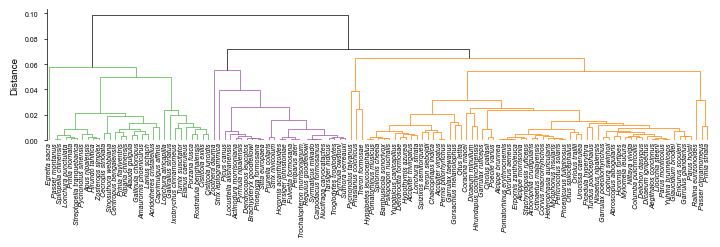

In [7]:
# Define the optimal number of clusters.
k_optimal = 3

# Compute hierarchical linkage.
linked = linkage(nichespace_deepsdm_all, method='average', metric='cosine')

# Generate cluster labels.
cluster_labels = fcluster(linked, t=k_optimal, criterion='maxclust')

# Determine distance threshold.
max_d = linked[-(k_optimal-1), 2]

# Plot the dendrogram.
fig, ax = plt.subplots(figsize=mm2inch(180, 60), constrained_layout = True)
set_link_color_palette(PU.color_list)
d_data = dendrogram(
    linked,
    orientation='top',
    distance_sort='ascending',
    show_leaf_counts=False,
    color_threshold=max_d,
    labels=[sp.replace('_', ' ') for sp in PU.species_list_predict if sp not in species_list_exclude],
    # labels=[sp.replace('_', ' ') for sp in PU.species_list_predict],     # Use this line if no species_list_exclude
    above_threshold_color = 'black',
    ax = ax
)

# Adjust x-axis tick labels (species names), font size, italic style.
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 5, fontstyle='italic', rotation=90, ha='center', va = 'top')
ax.set_ylabel('Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set consistent line width on the dendrogram lines.
for line_collection in ax.collections:
    line_collection.set_linewidth(0.5)

# Adjust tick label spacing.
ax.tick_params(axis='x', which='major', pad=-1)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'nichespace_clustering_dendrogram.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

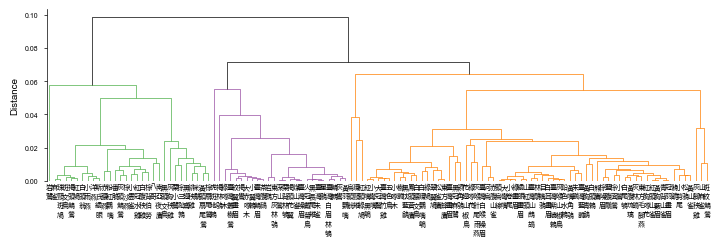

In [8]:
from matplotlib import font_manager as fm

# 設置字體為 Noto Sans CJK
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'  # 檢查該路徑是否存在
font_prop = fm.FontProperties(fname=font_path)

# Define the optimal number of clusters.
k_optimal = 3

# Compute hierarchical linkage.
linked = linkage(nichespace_deepsdm_all, method='average', metric='cosine')

# Generate cluster labels.
cluster_labels = fcluster(linked, t=k_optimal, criterion='maxclust')

# Determine distance threshold.
max_d = linked[-(k_optimal-1), 2]

# Plot the dendrogram.
fig, ax = plt.subplots(figsize=mm2inch(180, 60), constrained_layout = True)
set_link_color_palette(PU.color_list)
d_data = dendrogram(
    linked,
    orientation='top',
    distance_sort='ascending',
    show_leaf_counts=False,
    color_threshold=max_d,
    labels=[get_chinese_sciname(sp) for sp in PU.species_list_predict if sp not in species_list_exclude],
    above_threshold_color = 'black',
    ax = ax
)

# Adjust x-axis tick labels (species names), font size, italic style.
ls = [l.get_text() for l in ax.get_xticklabels()]
vls = ['\n'.join(list(l)) for l in ls]
ax.set_xticklabels(vls, fontsize = 4, ha='center', va = 'top', fontproperties = font_prop, rotation = 0)
ax.set_ylabel('Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set consistent line width on the dendrogram lines.
for line_collection in ax.collections:
    line_collection.set_linewidth(0.5)

# Adjust tick label spacing.
ax.tick_params(axis='x', which='major', pad=-1)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'nichespace_clustering_dendrogram_chinese.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

## Generate cluster-level average niches
The following code computes the average niche map for each identified cluster.

In [9]:
all_cluster_avg_niches = PU.get_all_cluster_average_nichespace(cluster_labels, nichespace_deepsdm_all_nonflatten)
img_sign = np.sign(all_cluster_avg_niches[0][1])

## Write cluster labels and average niche space data
Stores the computed labels and averages to YAML files for subsequent usage.

In [10]:
with open(PU.cluster_labels_path, 'w') as f:
    yaml.dump(cluster_labels.tolist(), f)
    
all_cluster_avg_niches_converted = {int(i):j.tolist() for i, j in all_cluster_avg_niches}
with open(PU.cluster_avg_nichespace_path, 'w') as f:
    yaml.dump(all_cluster_avg_niches_converted, f)

## Visualization of average niche space per cluster
Here, each cluster's mean niche space is saved as an image.

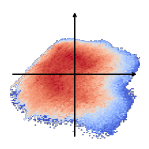

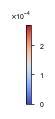

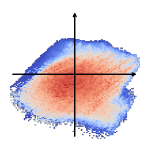

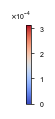

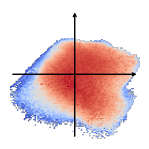

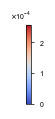

In [11]:
for (i_img, img) in all_cluster_avg_niches:
    fig, ax = plt.subplots(figsize = mm2inch(35, 35), constrained_layout = True)
    img_nan = np.where(img <= 0, np.nan, img)
    ax.imshow(img_nan, vmin = 0, cmap = 'coolwarm', extent = PU.nichespace_extent)
    ax.axis('off')

    # X-axis arrow.
    ax.annotate(
        '',
        xy=(6, 0),
        xytext=(-6, 0),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )

    # Y-axis arrow.
    ax.annotate(
        '',
        xy=(0, 6),
        xytext=(0, -6),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    plot_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_avg_cluster{i_img}.pdf')
    plt.savefig(plot_output, transparent = True, dpi = 500)
    plt.show()

    # Plot a separate colorbar for each cluster.
    fig_cb, ax_cb = plt.subplots(figsize = mm2inch(10, 25), gridspec_kw = {'left': 0.38, 'right': 0.5, 'bottom': 0.05, 'top': 0.85})
    norm = plt.Normalize(vmin = 0, vmax = np.nanmax(img_nan))
    cb = fig_cb.colorbar(plt.cm.ScalarMappable(norm = norm, cmap='coolwarm'), cax = ax_cb, orientation = 'vertical')

    formatter = mtick.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax_cb.yaxis.set_major_formatter(formatter)

    cb_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_avg_cluster{i_img}_colorbar.pdf')
    plt.savefig(cb_output, transparent=True, dpi=500)
    plt.show()

## Visualization of average niche space per cluster
Here, each cluster's mean niche space is saved as an image.

In [12]:
df_center = PU.calculate_deepsdm_nichespace_center(nichespace_deepsdm_all_nonflatten, cluster_labels)
df_center.to_csv(PU.df_nichespace_center_coordinate_path)
df_center

,PC01,PC02,cluster
Abroscopus_albogularis,0.776390,-0.778880,3
Accipiter_trivirgatus,0.568515,-0.691717,3
Accipiter_virgatus,0.646715,-0.656749,3
Acridotheres_cristatellus,-0.223778,-0.667487,1
Actinodura_morrisoniana,0.421784,-1.126376,2
...,...,...,...
Urocissa_caerulea,0.862855,-0.820650,3
Yuhina_brunneiceps,0.896700,-0.981503,3
Yungipicus_canicapillus,0.476620,-0.679137,3
Zoothera_dauma,0.623258,-0.930123,2


## Compute LDA of clustered niche centers

In [13]:
df_lda_result, df_ldaonPC, lda_explained_ratio, k_fold_validation = PU.calculate_nichecenter_cluster_lda()
df_lda_result

Stratified 5-fold CV accuracy: 0.925 (± 0.049)


,variable,importance_pc,loading_PC1,loading_PC2,proj_on_LD1,proj_on_LD2
0,tas,0.185427,0.024169,0.805828,0.517634,0.804448
1,EVI,0.182198,0.503656,0.436102,0.665506,0.417807
2,rsds,0.179846,-0.124006,0.880125,0.447210,0.883997
3,pr,0.157507,0.659089,0.219039,0.653287,0.195324
4,clt,0.105231,0.834228,-0.217276,0.520875,-0.246977
5,sfcWind,0.093294,-0.371025,-0.302449,-0.478614,-0.288985
6,hurs,0.089739,0.784748,-0.227632,0.475597,-0.255557
7,landcover_PC01,0.006586,0.233094,-0.114568,0.112211,-0.122833
8,landcover_PC02,0.000115,0.022847,-0.000007,0.017943,-0.000824
9,landcover_PC04,0.000051,0.013364,0.002243,0.011886,0.001764


In [31]:
df_ldaonPC.LD1.PC02 / df_ldaonPC.LD1.PC01

0.7877322010880757

## Overlap visualization of average clusters in niche space
Combines the top 50% density areas of each cluster's average niche, plus PCA loadings vectors.

In [14]:
unique_labels, label_to_color = PU.align_label_to_color(k_optimal, cluster_labels)

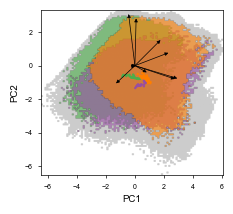

In [15]:
fig, ax = plt.subplots(figsize=mm2inch(55, 50), 
                       gridspec_kw = {'left': 0.15, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Display the background mask (significant region) in grey with transparency
ax.imshow(np.where(img_sign == 1, img_sign, np.nan),
          alpha=0.4,
          extent=PU.nichespace_extent,
          cmap=ListedColormap('grey'))
ax.set_aspect('auto')

# Overlay each cluster’s average niche region
for i_cluster, lbl in enumerate(unique_labels):
    # Get average niche map for the current cluster
    cluster_i_avg_niche = np.where(all_cluster_avg_niches[i_cluster][1] > 0,
                                   all_cluster_avg_niches[i_cluster][1],
                                   np.nan)
    # Define the threshold (50th percentile of non-NaN values)
    cluster_i_threshold = np.nanpercentile(cluster_i_avg_niche, 50)
    
    # Create a single-color colormap for this cluster
    single_cmap = ListedColormap([label_to_color[int(lbl)]]).copy()
    single_cmap.set_bad(alpha=0)
    
    # Display the thresholded cluster region
    ax.imshow(np.where(cluster_i_avg_niche >= cluster_i_threshold, 1, np.nan),
              extent=PU.nichespace_extent,
              cmap=single_cmap,
              alpha=0.6)
    ax.set_aspect('auto')

# Draw environmental variable vectors from the origin
for env in PU.env_list:
    dx = PU.env_pca_loadings.loc[env][f'PC{PU.x_pca:02d}'] * 3.5
    dy = PU.env_pca_loadings.loc[env][f'PC{PU.y_pca:02d}'] * 3.5
    ax.annotate(
        '',                              # No text, just an arrow
        xy=(dx, dy),                     # Arrow tip (end)
        xytext=(0, 0),                   # Arrow base (start)
        arrowprops=dict(
            arrowstyle='-|>',            # Arrowhead style
            lw=0.5,                      # Line width
            mutation_scale=5,            # Scale factor for arrowhead size (pt)
            fc='black',                  # Fill color (black)
            shrinkA=0,
            shrinkB=0
        )
    )

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Scatter plot of species niche centroids, colored by cluster label
point_colors = [label_to_color[int(lbl)] for lbl in cluster_labels]
ax.scatter(x=df_center['PC01'],
           y=df_center['PC02'],
           c=point_colors,
           s=0.5)

# Save figure as a transparent high-resolution PDF
plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'cluster_mean_env.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)

# Display the final figure
plt.show()

## Plot species niche centroids and the largest variance direction
Scatter plot of species-level PC1 vs PC2 plus a dashed line representing direction of maximum variance.

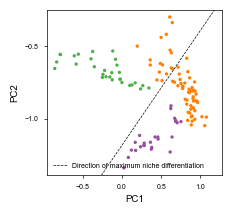

In [27]:
fig, ax = plt.subplots(figsize=mm2inch(55, 50), 
                       gridspec_kw = {'left': 0.18, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Scatter plot of species niche centroids in environmental PCA space
ax.scatter(x=df_center['PC01'],
           y=df_center['PC02'],
           c=point_colors,
           s=2)

# Calculate the centroid of all points (used to center the line of maximum variation)
center_x = df_center["PC01"].mean()
center_y = df_center["PC02"].mean()

# Compute and plot the line representing the direction of maximum variation among species niche centroids
# Equation: y = slope * (x - center_x) + center_y
x_vals_shifted = np.linspace(df_center["PC01"].min(), df_center["PC01"].max()+0.1, 100)
y_vals_shifted = df_ldaonPC.LD1.PC02 / df_ldaonPC.LD1.PC01 * (x_vals_shifted - center_x) + center_y

ax.plot(x_vals_shifted, y_vals_shifted,
        color="black",
        linestyle="--",
        linewidth=0.5,
        label="Direction of maximum niche differentiation")

# Add legend
ax.legend(loc='lower left', frameon=False)

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Define tick positions for both axes
ax.set_xticks([-0.5, 0, 0.5, 1])
ax.set_yticks([-1.0, -0.5])

# Set y-axis range slightly beyond data limits for better spacing
ax.set_ylim([df_center["PC02"].min() - 0.05,
             df_center["PC02"].max() + 0.05])

# Save figure as a transparent high-resolution PDF
plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'niche_center_LDAaxis1.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)

# Display plot
plt.show()


## Plot importance of environmental factors of LDA
Displays the importance of each environmental factor to LDA result.

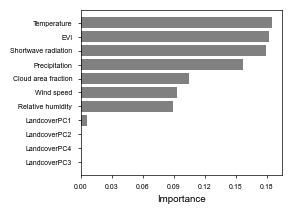

In [17]:
fig, ax = plt.subplots(figsize=mm2inch(70, 50), 
                       gridspec_kw = {'left': 0.26, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Get y-axis labels (according to the mapping in env_list_change dictionary)
y_labels = convert_to_env_list_detail(df_lda_result.variable)

# Plot each bar
for i, (env, value) in enumerate(zip(df_lda_result.variable,
                                     df_lda_result.importance_pc)):
    ax.barh(y_labels[i], value, color="grey")

# Set x-axis label
ax.set_xlabel("Importance")

# Set custom x-axis ticks
ax.set_xticks([0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Invert y-axis to show the most correlated variable at the top
ax.invert_yaxis()

# Remove background grid lines
ax.grid(False)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'lda_importance.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)
plt.show()

## Environmental medians violin plots of species among three clusters

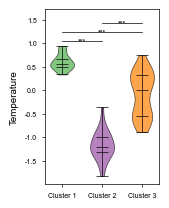

Overall Kruskal–Wallis (3 clusters): H=86.485, p=1.66e-19
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=40.179, p=2.32e-10
  Cluster 1 vs Cluster 3: H=47.837, p=4.63e-12
  Cluster 2 vs Cluster 3: H=49.211, p=2.3e-12
[Saved] Updated results for 'tas' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


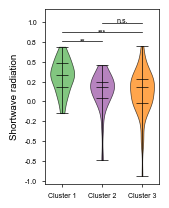

Overall Kruskal–Wallis (3 clusters): H=13.329, p=0.00128
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=8.650, p=0.00327
  Cluster 1 vs Cluster 3: H=11.769, p=0.000602
  Cluster 2 vs Cluster 3: H=0.038, p=0.845
[Saved] Updated results for 'rsds' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


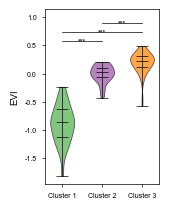

Overall Kruskal–Wallis (3 clusters): H=79.405, p=5.72e-18
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=39.326, p=3.59e-10
  Cluster 1 vs Cluster 3: H=60.251, p=8.35e-15
  Cluster 2 vs Cluster 3: H=23.653, p=1.15e-06
[Saved] Updated results for 'EVI' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


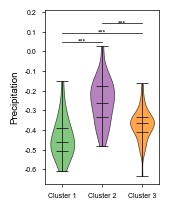

Overall Kruskal–Wallis (3 clusters): H=34.011, p=4.12e-08
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=23.534, p=1.23e-06
  Cluster 1 vs Cluster 3: H=11.987, p=0.000536
  Cluster 2 vs Cluster 3: H=19.135, p=1.22e-05
[Saved] Updated results for 'pr' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


In [19]:
species_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
# for env in PU.env_list:
for env in ['tas', 'rsds', 'EVI', 'pr']:
    PU.species_occ_env_violinplot(env, species_exclude)

## Distribution of environmental factors (沒用到)
Plots skewed-normal PDF and histograms of environment values across cluster members.

In [18]:
# Create output folder for environmental distribution plots by cluster
plot_output_folder = os.path.join(PU.plot_path_nichespace_clustering, 'cluster_env_distribution')
create_folder(plot_output_folder)

# Loop through each environmental variable
for env_plot in PU.env_list:
    print(convert_to_env_list_detail([env_plot])[0])
    
    # Retrieve environmental values for all clusters
    env_value_cluster_all = PU.get_cluster_env_values(cluster_labels, env_plot)

    # Determine the global min and max of the selected environmental variable
    env_min = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten().min()
    env_max = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten().max()

    # Plot distribution for each cluster
    for (i_cluster, env_value_cluster) in env_value_cluster_all:

        # Create a figure with defined margins
        fig, ax_pdf = plt.subplots(figsize=mm2inch(60, 30),
                                   gridspec_kw={'left': 0.18, 'right': 0.85, 'bottom': 0.25, 'top': 0.85})

        # Secondary y-axis for histogram
        ax_hist = ax_pdf.twinx()

        # Plot histogram of observed values (gray bars)
        ax_hist.hist(env_value_cluster, bins=30, density=False, alpha=0.5,
                     color='gray', label='Observed Data')
        ax_hist.set_ylabel('Frequency')

        # Format right y-axis labels
        formatter = mtick.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        formatter.format = lambda x, pos: f"{x:.1f}"
        ax_hist.yaxis.set_major_formatter(formatter)

        # Fit and plot skewed normal probability density function (PDF)
        x_vals = np.linspace(env_min, env_max, 300)
        a, loc, scale = skewnorm.fit(env_value_cluster)
        skewed_pdf = skewnorm.pdf(x_vals, a, loc, scale)

        # Plot fitted PDF (colored by cluster)
        ax_pdf.plot(x_vals, skewed_pdf, color=label_to_color[i_cluster], lw=0.5)
        ax_pdf.fill_between(x_vals, skewed_pdf, color=label_to_color[i_cluster], alpha=0.3)
        ax_pdf.set_ylabel('Density')
        ax_pdf.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

        # Draw a dashed line at the median of observed values
        median_val = np.median(env_value_cluster)
        print(median_val)
        ax_pdf.axvline(median_val, linestyle='--', color=label_to_color[i_cluster], linewidth=0.5)

        # Set axis labels and limits
        ax_pdf.set_xlabel(convert_to_env_list_detail([env_plot])[0])
        ax_pdf.set_xlim(env_min, env_max)
        ax_pdf.set_ylim(bottom=0)

        # Save plot as a transparent, high-resolution PDF
        plot_output = os.path.join(plot_output_folder, f'{env_plot}_{i_cluster}.pdf')
        plt.savefig(plot_output, dpi=500, transparent=True)

        # Display the figure
        plt.show()

## Plot species attention scores projected into niche PC space (沒用到）

In [214]:
import numpy as np
import pandas as pd

df_att = PU.df_attention.copy()         # 物種 × 11 變數
df_load = PU.env_pca_loadings.copy()    # 變數 × PCs（含 PC01, PC02, ...）

# 只取 PC1, PC2 的 loading；容錯處理欄名大小寫
pc1_col = next(c for c in df_load.columns if c.lower() in ['pc1','pc01'])
pc2_col = next(c for c in df_load.columns if c.lower() in ['pc2','pc02'])

# 變數名稱對齊（attention 欄名順序）：
# 1) 讓 loading 的 index 與 attention 的欄名一致
missing_in_load = set(df_att.columns) - set(df_load.index)
missing_in_att  = set(df_load.index) - set(df_att.columns)
print("缺在 loading 的變數：", missing_in_load)
print("缺在 attention 的變數：", missing_in_att)

# 若兩邊名字一致，建立 loading 矩陣 L：11×2，row 順序對齊 df_att.columns
L = df_load.loc[df_att.columns, [pc1_col, pc2_col]].to_numpy(float)   # (11,2)
var_names = list(df_att.columns)
print("L shape:", L.shape, "var order:", var_names[:5], "...")


缺在 loading 的變數： set()
缺在 attention 的變數： set()
L shape: (11, 2) var order: ['clt', 'hurs', 'pr', 'rsds', 'sfcWind'] ...


In [215]:
# A: (n_species, 11)
A = df_att.to_numpy(float)

# 投影到 PC 平面：Uhat = (L^T) @ A^T → 轉回 (n,2)
Uhat = (L.T @ A.T).T   # (n_species, 2)

# 單位化，便於比較方向（cosine）
Uhat = Uhat / (np.linalg.norm(Uhat, axis=1, keepdims=True) + 1e-12)

# 存成 DataFrame（每個物種在 PC 平面的「attention 方向」）
att_pc_dir = pd.DataFrame(Uhat, index=df_att.index, columns=['att_PC1','att_PC2'])
att_pc_dir.head()


,att_PC1,att_PC2
Species,,
Abroscopus_albogularis,0.968524,0.248920
Accipiter_trivirgatus,0.934914,0.354876
Accipiter_virgatus,0.939785,0.341765
Acridotheres_cristatellus,0.898146,0.439698
Actinodura_morrisoniana,0.977454,0.211148


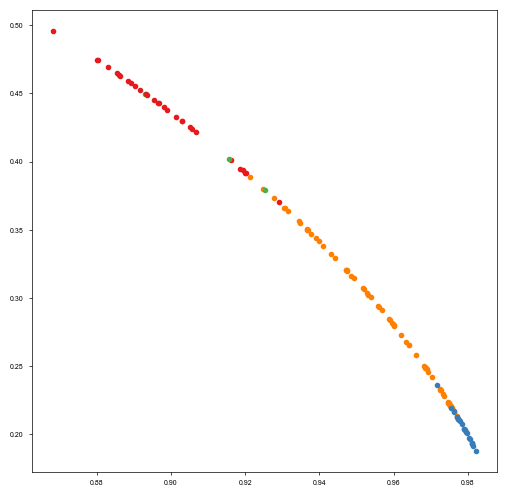

In [239]:
fig, ax = plt.subplots(figsize = (6, 6))
for i, sp in enumerate(PU.species_list_exclude):
    ax.scatter(x = att_pc_dir[att_pc_dir.index == sp].att_PC1.values[0], 
               y = att_pc_dir[att_pc_dir.index == sp].att_PC2.values[0], 
               color = PU.color_list[PU.cluster_labels[i]-1])

In [243]:
# 1) Covariance & eigen (use eigh for symmetric)
cov_matrix = np.cov(att_pc_dir[['att_PC1','att_PC2']].T)
evals, evecs = np.linalg.eigh(cov_matrix)          # eigenvectors are orthonormal
max_idx = np.argmax(evals)
dir_vec = evecs[:, max_idx]                         # already unit-length with eigh, but we can ensure:
dir_vec = dir_vec / np.linalg.norm(dir_vec)

# 2) Environmental factor loadings (each row = a factor's vector in PC space)
env = PU.env_pca_loadings[['PC01', 'PC02']].values  # shape: (n_factors, 2)
row_norms = np.linalg.norm(env, axis=1, keepdims=True)
# avoid divide-by-zero
safe_norms = np.where(row_norms == 0, 1.0, row_norms)
env_unit = env / safe_norms

# 3) Cosine similarity (magnitude-invariant)
cos_sim = env_unit @ dir_vec                         # shape: (n_factors,)
cos_sim_abs = np.abs(cos_sim)

# 4) 也可提供純投影（含量級）供參考
projection = env @ dir_vec                           # 受向量大小影響

# 5) 結果表
out = pd.DataFrame({
    "Environmental Factor": PU.env_pca_loadings.index,
    "Cosine with Max-Var Direction": cos_sim,        # 範圍 [-1, 1]，不受向量長度影響
    "Abs(Cosine)": cos_sim_abs,
    "Signed Projection": projection                  # 受向量長度影響（若你也想看「貢獻量」）
}).sort_values("Abs(Cosine)", ascending=False).reset_index(drop=True)

# 方向斜率（僅供繪圖/直覺解讀）
slope = dir_vec[1] / dir_vec[0] if dir_vec[0] != 0 else np.inf

## Plot PCA results of species attention scores (沒用到)

In [279]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# 1) 準備資料（標準化每一欄；若已確認尺度近似也可略過）
X = PU.df_attention.copy()             # shape: (n_species, 11)
Xz = StandardScaler().fit_transform(X)  # 每欄標準化
Xz = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)  # z-score by column

# 2) PCA
pca = PCA(n_components=Xz.shape[1], svd_solver='full')
pca.fit(Xz)
scores = pca.transform(Xz)                                # species × PCs
eigvals = pca.explained_variance_                         # λ_k
var_ratio = pca.explained_variance_ratio_                 # w_k
# "correlation-style" loadings: variables × PCs
loadings = pca.components_.T * np.sqrt(eigvals)           # (11, 11)
var_names = list(X.columns)
pc_names = [f'PC{i+1:02d}' for i in range(loadings.shape[1])]
df_load = pd.DataFrame(loadings, index=var_names, columns=pc_names)

# 3) 每個變數對每個 PC 的「貢獻」 ctr_{j,k} = loading^2 / λ_k
ctr = (loadings**2) / eigvals[np.newaxis, :]              # (11, 11)
df_ctr = pd.DataFrame(ctr, index=var_names, columns=pc_names)

# 4) 取前 K 個 PC 的「整體重要性」 Imp_j = sum_k w_k * loading_{j,k}^2
K = 2  # 可改：選到累積變異 >= 0.80 之 K
w = var_ratio[:K]
Imp = (loadings[:, :K]**2 @ w)                            # shape: (11,)
df_imp = pd.DataFrame({'variable': var_names, 'overall_importance': Imp})
df_imp = df_imp.sort_values('overall_importance', ascending=False)

# 5) 同場加映：列出「PC1 組成」與「PC2 組成」的排序（看絕對 loading 或 ctr）
pc1_rank = df_load['PC01'].abs().sort_values(ascending=False)
pc2_rank = df_load['PC02'].abs().sort_values(ascending=False)

print("=== 變數的整體重要性（跨前 K 個 PC，加權）===")
print(df_imp.to_string(index=False))

print("\n=== PC1 組成（|loading| 由大到小）===")
print(pc1_rank.to_string())

print("\n=== PC2 組成（|loading| 由大到小）===")
print(pc2_rank.to_string())

# 6) 若要圖（條圖），可拿 df_imp 做 barplot；或對 df_ctr[['PC01','PC02']] 做堆疊比較。


=== 變數的整體重要性（跨前 K 個 PC，加權）===
      variable  overall_importance
landcover_PC02            0.995172
landcover_PC01            0.994951
           EVI            0.994088
          hurs            0.993345
            pr            0.988985
       sfcWind            0.988126
          rsds            0.986890
landcover_PC03            0.981577
           tas            0.974096
           clt            0.960113
landcover_PC04            0.951646

=== PC1 組成（|loading| 由大到小）===
landcover_PC02    1.004016
landcover_PC01    1.003903
EVI               1.003462
hurs              1.003082
pr                1.000850
sfcWind           1.000409
rsds              0.999775
landcover_PC03    0.997046
tas               0.993189
clt               0.985947
landcover_PC04    0.981530

=== PC2 組成（|loading| 由大到小）===
landcover_PC04    0.209414
clt               0.186645
tas               0.147097
landcover_PC03    0.117856
rsds              0.092195
sfcWind           0.085095
pr                0.079515
hu

In [280]:
df_att = PU.df_attention.copy()         # 物種 × 11 變數
# df_load = df_load.copy()    # 變數 × PCs（含 PC01, PC02, ...）

# 只取 PC1, PC2 的 loading；容錯處理欄名大小寫
pc1_col = next(c for c in df_load.columns if c.lower() in ['pc1','pc01'])
pc2_col = next(c for c in df_load.columns if c.lower() in ['pc2','pc02'])

# 變數名稱對齊（attention 欄名順序）：
# 1) 讓 loading 的 index 與 attention 的欄名一致
missing_in_load = set(df_att.columns) - set(df_load.index)
missing_in_att  = set(df_load.index) - set(df_att.columns)
print("缺在 loading 的變數：", missing_in_load)
print("缺在 attention 的變數：", missing_in_att)

# 若兩邊名字一致，建立 loading 矩陣 L：11×2，row 順序對齊 df_att.columns
L = df_load.loc[df_att.columns, [pc1_col, pc2_col]].to_numpy(float)   # (11,2)
var_names = list(df_att.columns)
print("L shape:", L.shape, "var order:", var_names[:5], "...")


缺在 loading 的變數： set()
缺在 attention 的變數： set()
L shape: (11, 2) var order: ['clt', 'hurs', 'pr', 'rsds', 'sfcWind'] ...


In [281]:
# A: (n_species, 11)
A = df_att.to_numpy(float)

# 投影到 PC 平面：Uhat = (L^T) @ A^T → 轉回 (n,2)
Uhat = (L.T @ A.T).T   # (n_species, 2)

# 單位化，便於比較方向（cosine）
Uhat = Uhat / (np.linalg.norm(Uhat, axis=1, keepdims=True) + 1e-12)

# 存成 DataFrame（每個物種在 PC 平面的「attention 方向」）
att_pc_dir = pd.DataFrame(Uhat, index=df_att.index, columns=['att_PC1','att_PC2'])
att_pc_dir.head()


,att_PC1,att_PC2
Species,,
Abroscopus_albogularis,-0.997853,0.065489
Accipiter_trivirgatus,-0.993705,0.112025
Accipiter_virgatus,-0.994552,0.104241
Acridotheres_cristatellus,-0.978801,0.204815
Actinodura_morrisoniana,-0.998525,0.054299


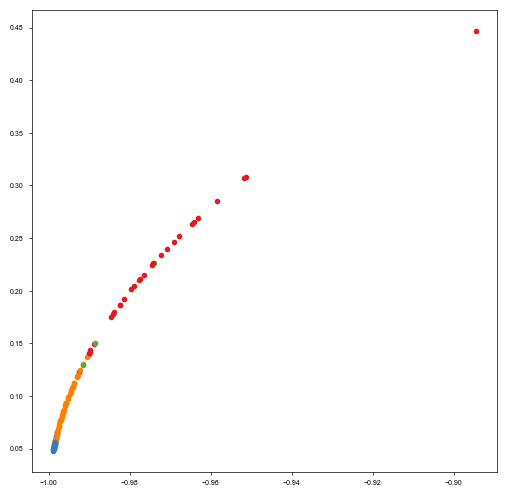

In [282]:
fig, ax = plt.subplots(figsize = (6, 6))
for i, sp in enumerate(PU.species_list_exclude):
    ax.scatter(x = att_pc_dir[att_pc_dir.index == sp].att_PC1.values[0], 
               y = att_pc_dir[att_pc_dir.index == sp].att_PC2.values[0], 
               color = PU.color_list[PU.cluster_labels[i]-1])

In [283]:
corr = Xz.corr()
print(corr.round(2))


                 clt  hurs    pr  rsds  sfcWind   tas   EVI  landcover_PC01  landcover_PC02  landcover_PC03  landcover_PC04
clt             1.00  0.97 -0.99 -0.96    -0.96 -0.94  0.99            0.98           -0.98            0.95            1.00
hurs            0.97  1.00 -0.99 -1.00    -1.00 -0.99  1.00            1.00           -1.00            1.00            0.97
pr             -0.99 -0.99  1.00  0.99     0.99  0.97 -1.00           -1.00            1.00           -0.98           -0.99
rsds           -0.96 -1.00  0.99  1.00     1.00  1.00 -0.99           -1.00            1.00           -1.00           -0.95
sfcWind        -0.96 -1.00  0.99  1.00     1.00  1.00 -0.99           -1.00            1.00           -1.00           -0.96
tas            -0.94 -0.99  0.97  1.00     1.00  1.00 -0.98           -0.99            0.99           -1.00           -0.94
EVI             0.99  1.00 -1.00 -0.99    -0.99 -0.98  1.00            1.00           -1.00            0.99            0.98
landcove

In [284]:
pc2 = df_load['PC02'].sort_values(key=np.abs, ascending=False)
pc3 = df_load['PC03'].sort_values(key=np.abs, ascending=False)
print(pc2, pc3)


landcover_PC04    0.209414
clt               0.186645
tas               0.147097
landcover_PC03   -0.117856
rsds              0.092195
sfcWind           0.085095
pr               -0.079515
hurs             -0.043462
EVI               0.033071
landcover_PC01   -0.014511
landcover_PC02    0.003253
Name: PC02, dtype: float64 clt               0.033641
landcover_PC04   -0.028422
landcover_PC03    0.008477
landcover_PC01   -0.005592
EVI              -0.005492
pr               -0.004597
rsds              0.003055
landcover_PC02    0.002265
sfcWind           0.001756
hurs             -0.000460
tas              -0.000349
Name: PC03, dtype: float64


## 方向性梯度敏感度（Directional Sensitivity）(沒用到)
對每個物種的 niche raster \(S(PC1, PC2)\) 計算在**每一個原始環境因子方向**（由該因子在 PC1、PC2 的 loading 決定）上的**方向導數能量**：
$$ \mathcal{D}_{ij} = \sum_{p} w_i(p)\, (\nabla S_i(p) \cdot \mathbf{v}_j)^2, \quad w_i(p)=\frac{S_i(p)}{\sum_p S_i(p)} $$
其中 \(\mathbf{v}_j\) 是第 *j* 變數在 PC 平面的單位向量。此值愈大，表示該物種對**該環境梯度**的**敏感度**愈強。

最後，對四個群（cluster）取平均並以**置換 ANOVA**檢驗群間差異，給出**『變數 × 群』敏感度熱圖**與排序。

PC 來源與 loading 參考你的主文與 biplot 圖（僅解釋 PC1–PC2 子空間）。 fileciteturn0file0 fileciteturn0file1

In [191]:
# Cell 1 — 環境設定與套件
import os, glob, math, warnings, sys, pathlib
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

SEED = 42

# ---- 使用者需檢查/修改的設定 ----
H5_ROOT = PU.plot_path_nichespace_h5                                       # 你的 h5 目錄
H5_DATASET_KEY = 'deepsdm_all_month_max'                                   # raster 資料集名稱
LOADINGS_CSV = PU.env_pca_loadings_path                                    # 11×2 的 loading 表（PC1, PC2）
CLUSTERS_CSV = PU.df_nichespace_center_coordinate_path                     # 物種名與分群（用於群間比較）

N_PERM = 999     # 群間差異的置換檢定次數

In [192]:
# Cell 2 — 輔助函式：讀 loading、讀 H5、梯度與方向能量、置換 ANOVA
def detect_pc_columns(df: pd.DataFrame):
    cand = [('PC1','PC2'),('pc1','pc2'),('PC01','PC02'),('Dim1','Dim2'),('Comp.1','Comp.2'),('PC_1','PC_2'),('PC 1','PC 2')]
    low = {c.lower(): c for c in df.columns}
    for a,b in cand:
        if a in df.columns and b in df.columns: return a,b
        if a.lower() in low and b.lower() in low: return low[a.lower()], low[b.lower()]
    nums = df.select_dtypes(include=[np.number]).columns.tolist()
    assert len(nums)>=2, 'loadings 檔案未找到 PC1/PC2 欄位'; return nums[0], nums[1]

def tidy_var_index(load_df: pd.DataFrame, pc1_col: str, pc2_col: str) -> pd.DataFrame:
    if np.issubdtype(load_df.index.dtype, np.number):
        candidates = [c for c in load_df.columns if c not in [pc1_col, pc2_col]]
        chosen = None
        for c in candidates:
            if load_df[c].dtype == object: chosen = c; break
        if chosen is not None: load_df = load_df.set_index(chosen)
        else: load_df.index = [f'var_{i+1}' for i in range(load_df.shape[0])]
    return load_df

def norm_name(s: str) -> str:
    s = s.strip().lower().replace(' ', '_').replace('-', '_')
    s = ''.join(ch for ch in s if ch.isalnum() or ch == '_')
    return s

def species_name_from_path(p: str) -> str:
    return norm_name(os.path.splitext(os.path.basename(p))[0])

def read_h5_raster(path: str, key: str):
    with h5py.File(path, 'r') as h5f:
        arr = np.array(h5f[key][:], dtype=float)
        meta = {}
        H, W = arr.shape
        meta['pc1'] = np.linspace(PU.pc_info['PC01_min'], PU.pc_info['PC01_max'], W)
        meta['pc2'] = np.linspace(PU.pc_info['PC02_min'], PU.pc_info['PC02_max'], H)
    return arr, meta

def suitability_normalize(S, eps=1e-12):
    S = np.asarray(S, float)
    tot = S.sum()
    if not np.isfinite(tot) or tot <= 0: return np.full_like(S, 1.0 / S.size)
    return S / (tot + eps)

import numpy as np
from typing import Tuple

def _fix_coords_strictly_increasing(a: np.ndarray) -> np.ndarray:
    """確保座標向量嚴格遞增；遇到重複/倒退就加一個極小 eps。"""
    a = np.asarray(a, float).copy()
    # 若全是 NaN 或長度<2，回退為等距
    if a.ndim != 1 or a.size < 2 or not np.isfinite(a).any():
        return None
    # 將 NaN 以線性插值/中位數處理（簡化：先用中位數塞掉 NaN）
    if np.isnan(a).any():
        med = np.nanmedian(a)
        a = np.where(np.isfinite(a), a, med)
    rng = float(np.max(a) - np.min(a))
    eps = max(1e-12, 1e-9 * (rng if rng > 0 else 1.0))
    for i in range(1, a.size):
        if not np.isfinite(a[i]) or a[i] <= a[i-1]:
            a[i] = a[i-1] + eps
    return a

def gradient_components(S: np.ndarray, pc2_vec: np.ndarray, pc1_vec: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    用 PC2、PC1 的『座標向量本身』做 spacing，計算 ∂S/∂PC1 (Gx) 與 ∂S/∂PC2 (Gy)。
    - 自動修正座標中的重複/非遞增/NaN。
    - 對梯度輸出做 NaN→0 的安全處理。
    """
    S = np.asarray(S, float)
    H, W = S.shape

    pc2 = np.asarray(pc2_vec, float) if pc2_vec is not None else None
    pc1 = np.asarray(pc1_vec, float) if pc1_vec is not None else None

    # 座標檢查與修正；必要時回退為等距
    pc2_fixed = _fix_coords_strictly_increasing(pc2) if pc2 is not None and pc2.ndim == 1 and pc2.size == H else None
    pc1_fixed = _fix_coords_strictly_increasing(pc1) if pc1 is not None and pc1.ndim == 1 and pc1.size == W else None

    if pc2_fixed is None:
        pc2_fixed = np.linspace(0.0, 1.0, H)
    if pc1_fixed is None:
        pc1_fixed = np.linspace(0.0, 1.0, W)

    # 清理 S 的非數值
    S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)

    # 用「座標向量」當 spacing；為了穩定可先用 edge_order=1
    Gy, Gx = np.gradient(S, pc2_fixed, pc1_fixed, edge_order=1)  # Gy 對 PC2、Gx 對 PC1

    # 安全處理：避免 NaN/inf 汙染後續計算
    Gx = np.nan_to_num(Gx, nan=0.0, posinf=0.0, neginf=0.0)
    Gy = np.nan_to_num(Gy, nan=0.0, posinf=0.0, neginf=0.0)
    return Gx, Gy


def directional_energy(S: np.ndarray, Gx: np.ndarray, Gy: np.ndarray, v: np.ndarray) -> float:
    # v: unit vector in PC space (vx, vy)
    dSdv = Gx * v[0] + Gy * v[1]
    W = suitability_normalize(S)
    return float(np.sum(W * (dSdv**2)))

def oneway_perm_anova(values: np.ndarray, groups: np.ndarray, n_perm=999, rng=None):
    # values: (n,) for one variable across species; groups: (n,) cluster labels
    # F = MS_between / MS_within
    df = pd.DataFrame({'val': values, 'grp': groups})
    grps = [g['val'].values for _, g in df.groupby('grp')]
    n = len(values)
    k = len(grps)
    grand_mean = values.mean()
    ss_between = sum(len(g)* (g.mean() - grand_mean)**2 for g in grps)
    ss_within = sum(((g - g.mean())**2).sum() for g in grps)
    ms_between = ss_between / max(k-1, 1)
    ms_within  = ss_within  / max(n-k, 1)
    F_obs = ms_between / (ms_within + 1e-12)
    if rng is None: rng = np.random.default_rng(2024)
    null = np.zeros(n_perm, float)
    for i in range(n_perm):
        perm = rng.permutation(groups)
        dfp = pd.DataFrame({'val': values, 'grp': perm})
        grpsp = [g['val'].values for _, g in dfp.groupby('grp')]
        ssb = sum(len(g)* (g.mean() - grand_mean)**2 for g in grpsp)
        ssw = sum(((g - g.mean())**2).sum() for g in grpsp)
        msb = ssb / max(k-1, 1)
        msw = ssw / max(n-k, 1)
        null[i] = msb / (msw + 1e-12)
    p = (1.0 + (null >= F_obs).sum()) / (1.0 + n_perm)
    return F_obs, p, null


In [193]:
# Cell 3 — 讀取 loading、clusters 與 H5 rasters（修正版：clusters 的第 1 欄為物種 row name）
import pandas as pd
import os, glob
import numpy as np

# 讀 loading
load_df = pd.read_csv(LOADINGS_CSV, index_col = 0)
pc1_L, pc2_L = detect_pc_columns(load_df)
load_df = tidy_var_index(load_df, pc1_L, pc2_L)
L = load_df[[pc1_L, pc2_L]].to_numpy(float)        # (11, 2)
var_names = load_df.index.astype(str).tolist()

# 讀 cluster（重點修改：第 1 欄讀成 index=物種）
# 若你的 CSV 第一列就是欄名（如：空白/Species, PC01, PC02, cluster），這行會把「第 1 欄」當 index。
# 如果你的檔根本沒有欄名，請改成：pd.read_csv(CLUSTERS_CSV, index_col=0, header=None)
clu_df = pd.read_csv(CLUSTERS_CSV, index_col=0)

# 把 index 標準化，確保能對上 H5 檔名（Zosterops_simplex.h5 → 'zosterops_simplex'）
clu_df.index = clu_df.index.map(lambda s: norm_name(str(s)))

# 找出群別欄位（大小寫皆可）
cand = ['cluster','Cluster','group','grp','label','k','class']
clu_col = next((c for c in clu_df.columns if c in cand or c.lower() in [x.lower() for x in cand]), None)
if clu_col is None:
    raise RuntimeError("clusters CSV 未找到分群欄位（請用欄名 'cluster' 或同義字）")

# 物種 → 群別 的對照表
clusters_map = clu_df[clu_col].astype(str).to_dict()

# 收集 H5 檔
h5_files = sorted([H5_ROOT.replace('[SPECIES]', sp) for sp in PU.species_list_exclude])
print("H5 檔案數：", len(h5_files))

# 讀一個檔案取得 PC 軸（若 H5 無座標向量，會 fallback 到 [-6,6]）
PC1_vec = PC2_vec = None
first_ok = None
for path in h5_files:
    S, meta = read_h5_raster(path, H5_DATASET_KEY)
    PC1_vec = meta.get('pc1', np.linspace(PU.pc_info['PC01_min'], PU.pc_info['PC01_max'],S.shape[1]))
    PC2_vec = meta.get('pc2', np.linspace(PU.pc_info['PC02_min'], PU.pc_info['PC02_max'],S.shape[0]))
    first_ok = S.shape
    break
print("Raster 形狀：", first_ok, "；PC1/PC2 軸長度：", len(PC1_vec), len(PC2_vec))

# 構建每個原始環境變數在 PC 平面的單位方向向量 v_j
V = []
for j in range(L.shape[0]):
    v = L[j, :].astype(float)
    nrm = np.linalg.norm(v)
    V.append(np.zeros(2) if nrm < 1e-12 else v / nrm)
V = np.stack(V, axis=0)   # (p, 2)


H5 檔案數： 121
Raster 形狀： (100, 100) ；PC1/PC2 軸長度： 100 100


In [195]:
def _diagnose_coords(pc1_vec, pc2_vec):
    pc1 = np.asarray(pc1_vec, float)
    pc2 = np.asarray(pc2_vec, float)
    print("PC1 shape:", pc1.shape, "min/max:", np.nanmin(pc1), np.nanmax(pc1))
    print("PC2 shape:", pc2.shape, "min/max:", np.nanmin(pc2), np.nanmax(pc2))
    d1 = np.diff(pc1); d2 = np.diff(pc2)
    print("PC1 min diff:", np.nanmin(d1), " #zeros:", np.sum(d1==0))
    print("PC2 min diff:", np.nanmin(d2), " #zeros:", np.sum(d2==0))
    if not np.all(np.isfinite(pc1)): print("PC1 has non-finite!")
    if not np.all(np.isfinite(pc2)): print("PC2 has non-finite!")

_diagnose_coords(PC1_vec, PC2_vec)


PC1 shape: (100,) min/max: -6.542660236358643 6.119082450866699
PC2 shape: (100,) min/max: -6.588436126708984 3.388925790786743
PC1 min diff: 0.12789639078005344  #zeros: 0
PC2 min diff: 0.10078143351005764  #zeros: 0


In [196]:
# Cell 4 — 主計算（修正版）
species, clusters, energies = [], [], []
shapes_ok = 0

for path in h5_files:
    sp = species_name_from_path(path)
    S, meta = read_h5_raster(path, H5_DATASET_KEY)
    # 尺寸檢查
    if S.shape != first_ok:
        print(f'跳過 {sp}（尺寸不符 {S.shape}）'); continue
    # 取得 cluster（若沒有則標示為 'NA'）
    grp = clusters_map.get(sp, 'NA')

    # 計算梯度（使用修正版座標處理）
    Gx, Gy = gradient_components(S, PC2_vec, PC1_vec)

    # 加權方向能量
    row = []
    for j in range(V.shape[0]):
        v = V[j]
        if v[0] == 0 and v[1] == 0:
            row.append(0.0)
        else:
            dSdv = Gx * v[0] + Gy * v[1]
            dSdv = np.nan_to_num(dSdv, nan=0.0, posinf=0.0, neginf=0.0)
            row.append(directional_energy(S, Gx, Gy, v))
    species.append(sp); clusters.append(grp); energies.append(row)
    shapes_ok += 1

energies = np.array(energies)  # (n, p)
print(f'完成計算：{energies.shape[0]} 物種 × {energies.shape[1]} 變數')
df_energy = pd.DataFrame(energies, columns=var_names, index=species)
df_energy.insert(0, 'cluster', clusters)
display(df_energy.head())

out_energy = os.path.join(PU.plot_path_nichespace_clustering, 'directional_sensitivity_by_species.csv')
df_energy.to_csv(out_energy)
print("Saved:", out_energy)


完成計算：121 物種 × 11 變數


,cluster,clt,hurs,pr,rsds,sfcWind,tas,EVI,landcover_PC01,landcover_PC02,landcover_PC03,landcover_PC04
abroscopus_albogularis,4,0.131639,0.132495,0.144175,0.215580,0.174287,0.220126,0.176996,0.140769,0.130128,0.134669,0.135388
accipiter_trivirgatus,4,0.136393,0.137221,0.155581,0.236875,0.192837,0.243605,0.196093,0.146026,0.136531,0.143096,0.144071
accipiter_virgatus,4,0.115867,0.116742,0.127958,0.199758,0.157927,0.204167,0.160633,0.125127,0.114154,0.118574,0.119280
acridotheres_cristatellus,1,0.096125,0.095661,0.133734,0.171664,0.168447,0.183862,0.170970,0.096181,0.107022,0.118216,0.119589
actinodura_morrisoniana,2,0.068268,0.068355,0.083465,0.114760,0.102530,0.119820,0.104057,0.070767,0.071274,0.076017,0.076642


Saved: plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/directional_sensitivity_by_species.csv


In [197]:
# Cell 5 — 群別平均、置換 ANOVA 與顯著性排名
# 只保留有 cluster 標籤的物種
df_valid = df_energy[df_energy['cluster']!='NA'].copy()
labels = df_valid['cluster'].astype(str).to_numpy()
X = df_valid[var_names].to_numpy()

# 置換 ANOVA（每個變數一個檢定）
F_list, p_list = [], []
for j, vname in enumerate(var_names):
    F, p, null = oneway_perm_anova(X[:, j], labels, n_perm=N_PERM, rng=rng)
    F_list.append(F); p_list.append(p)

res = pd.DataFrame({'variable': var_names, 'F_perm': F_list, 'p_perm': p_list})
res = res.sort_values('F_perm', ascending=False)

# 群內平均
grp_mean = df_valid.groupby('cluster')[var_names].mean()

display(res.head(12))
display(grp_mean)

out_res = os.path.join(PU.plot_path_nichespace_clustering, 'directional_sensitivity_tests.csv')
out_grp = os.path.join(PU.plot_path_nichespace_clustering, 'directional_sensitivity_cluster_means.csv')
res.to_csv(out_res, index=False); grp_mean.to_csv(out_grp)
print("Saved:", out_res, "and", out_grp)

,variable,F_perm,p_perm
4,sfcWind,31.631930,0.001
6,EVI,31.417796,0.001
2,pr,29.137243,0.001
10,landcover_PC04,24.861357,0.001
9,landcover_PC03,24.323512,0.001
8,landcover_PC02,19.036228,0.001
5,tas,16.109231,0.001
3,rsds,13.122625,0.001
0,clt,11.869289,0.001
1,hurs,11.386909,0.001


,clt,hurs,pr,rsds,sfcWind,tas,EVI,landcover_PC01,landcover_PC02,landcover_PC03,landcover_PC04
cluster,,,,,,,,,,,
1,0.137496,0.136452,0.198270,0.242533,0.248991,0.262105,0.252526,0.134945,0.156596,0.174448,0.176591
2,0.085109,0.085303,0.103449,0.146384,0.128088,0.152533,0.130095,0.088926,0.088284,0.094079,0.094857
3,0.113098,0.113802,0.125114,0.186791,0.151843,0.191094,0.154224,0.120800,0.112242,0.116501,0.117160
4,0.119584,0.120362,0.131256,0.196652,0.158952,0.200877,0.161439,0.127915,0.118273,0.122486,0.123150


Saved: plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/directional_sensitivity_tests.csv and plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/directional_sensitivity_cluster_means.csv


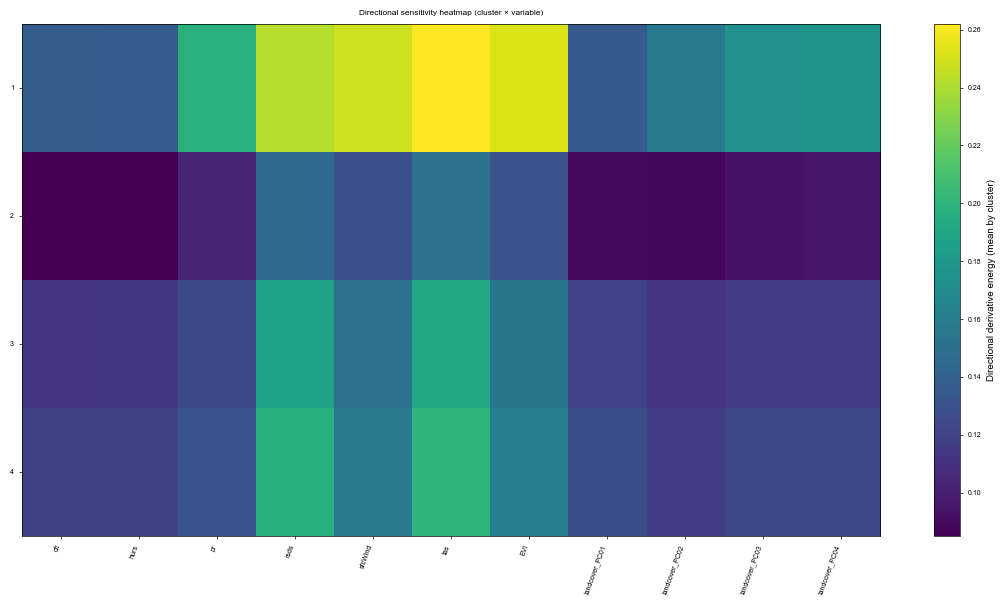

Saved: plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/directional_sensitivity_heatmap.png


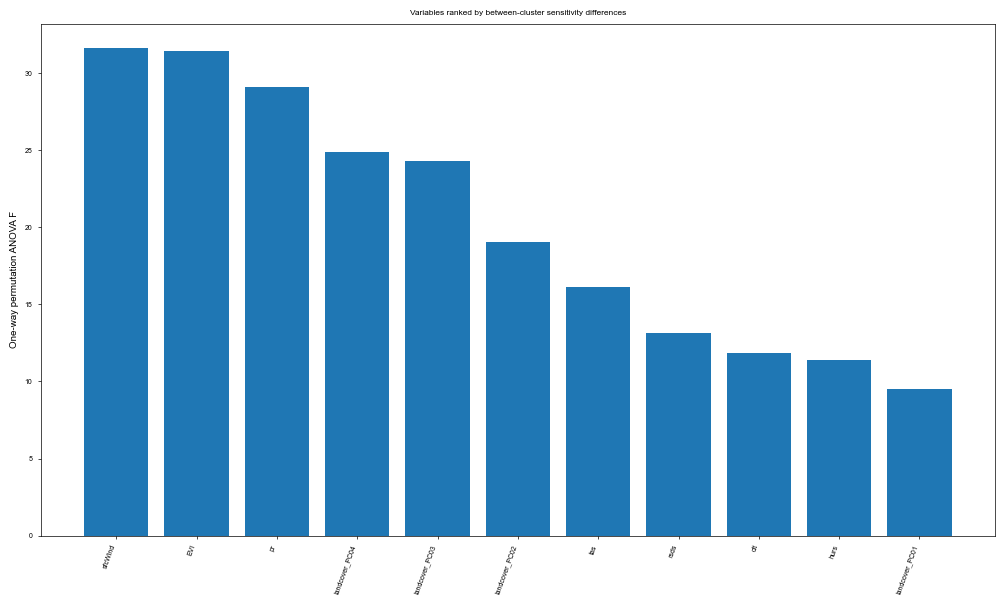

Saved: plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/directional_sensitivity_rank_bar.png


In [198]:
# Cell 6 — 視覺化：群別 × 變數熱圖 & 變數排序（F 統計）
# 熱圖（各群的平均敏感度）
plt.figure(figsize=(11, 6))
plt.imshow(grp_mean[var_names].to_numpy(), aspect='auto')
plt.xticks(range(len(var_names)), var_names, rotation=70, ha='right')
plt.yticks(range(len(grp_mean.index)), grp_mean.index.tolist())
plt.colorbar(label='Directional derivative energy (mean by cluster)')
plt.title('Directional sensitivity heatmap (cluster × variable)')
plt.tight_layout()
heat_path = os.path.join(PU.plot_path_nichespace_clustering, 'directional_sensitivity_heatmap.png')
plt.savefig(heat_path, dpi=180)
plt.show()
print("Saved:", heat_path)

# 變數以 F 排序的長條圖
plt.figure(figsize=(10,6))
plt.bar(res['variable'], res['F_perm'])
plt.xticks(rotation=70, ha='right')
plt.ylabel('One-way permutation ANOVA F')
plt.title('Variables ranked by between-cluster sensitivity differences')
plt.tight_layout()
bar_path = os.path.join(PU.plot_path_nichespace_clustering, 'directional_sensitivity_rank_bar.png')
plt.savefig(bar_path, dpi=180)
plt.show()
print("Saved:", bar_path)

## dbRDA（完整 raster 形狀）— 以 Hellinger 距離 + PCoA + 線性約束（RDA）(沒用到)
本 notebook 直接以**每個物種的 100×100 niche raster**為反應，建立物種間的 **Hellinger 距離**，再以 **PCoA** 投影到歐式空間，最後以物種層級的原始環境因子表徵（由 PC1/PC2 與 loading 回推）做 **RDA**（距離型冗餘分析的等價程序）。

**重要說明**：你的 PC1、PC2 來自 11 個環境因子的 PCA（前兩軸合計解釋 ~36–37% 變異），且你已有變數箭頭圖與 loading 表。此 notebook 中對原始環境因子的回推與解讀都**限定在 PC1–PC2 子空間**，與你的研究分群空間一致。（方法與圖示背景，參見你的主文與 biplot 圖。）

參考：PC 來源與載荷表、PC 平面箭頭示意。 fileciteturn0file0 fileciteturn0file1 fileciteturn0file2

In [199]:
# Cell 1 — 環境設定與套件
import os, glob, math, warnings, sys, pathlib
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

SEED = 2024

# ---- 使用者需檢查/修改的設定 ----
H5_ROOT = PU.plot_path_nichespace_h5                                       # 你的 h5 目錄
H5_DATASET_KEY = 'deepsdm_all_month_max'                                   # raster 資料集名稱
LOADINGS_CSV = PU.env_pca_loadings_path                                    # 11×2 的 loading 表（PC1, PC2）
CLUSTERS_CSV = PU.df_nichespace_center_coordinate_path                     # 物種名與分群（用於群間比較）

N_PERM   = 999    # 置換次數（全模型 & 變數邊際測試）
MIN_SPEC = 10     # 讀檔時，若種數低於此值則警示


In [200]:
# Cell 2 — 輔助函式：讀 loading、讀 H5、名稱對齊、距離/PCoA/RDA/置換
from typing import Optional

def detect_pc_columns(df: pd.DataFrame) -> Tuple[str, str]:
    cand = [('PC1','PC2'),('pc1','pc2'),('PC01','PC02'),('Dim1','Dim2'),('Comp.1','Comp.2'),('PC_1','PC_2'),('PC 1','PC 2')]
    low = {c.lower(): c for c in df.columns}
    for a,b in cand:
        if a in df.columns and b in df.columns: return a,b
        if a.lower() in low and b.lower() in low: return low[a.lower()], low[b.lower()]
    nums = df.select_dtypes(include=[np.number]).columns.tolist()
    assert len(nums) >= 2, 'loadings 檔案未找到 PC1/PC2 欄位'; return nums[0], nums[1]

def tidy_var_index(load_df: pd.DataFrame, pc1_col: str, pc2_col: str) -> pd.DataFrame:
    if np.issubdtype(load_df.index.dtype, np.number):
        candidates = [c for c in load_df.columns if c not in [pc1_col, pc2_col]]
        chosen = None
        for c in candidates:
            if load_df[c].dtype == object: chosen = c; break
        if chosen is not None: load_df = load_df.set_index(chosen)
        else: load_df.index = [f'var_{i+1}' for i in range(load_df.shape[0])]
    return load_df

def norm_name(s: str) -> str:
    s = s.strip().lower().replace(' ', '_').replace('-', '_')
    s = ''.join(ch for ch in s if ch.isalnum() or ch == '_')
    return s

def species_name_from_path(p: str) -> str:
    return norm_name(os.path.splitext(os.path.basename(p))[0])

def read_h5_raster(path: str, key: str) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    with h5py.File(path, 'r') as h5f:
        if key not in h5f:  # 嘗試其他常見名稱
            for alt in ['niche', 'S', 'raster', 'data']:
                if alt in h5f:
                    key = alt; break
        arr = h5f[key][:]
        meta = {}
        # 嘗試讀取座標（若提供）
        for cand in ['pc1','PC1','x','pc1_vec','PC1_vec','pc1_ticks','pc1_bins','pc1_edges']:
            if cand in h5f: meta['pc1'] = np.array(h5f[cand][:]); break
        for cand in ['pc2','PC2','y','pc2_vec','PC2_vec','pc2_ticks','pc2_bins','pc2_edges']:
            if cand in h5f: meta['pc2'] = np.array(h5f[cand][:]); break
        # 或讀 attribute
        if 'pc1' not in meta:
            for a in ['pc1_min','PC1_min','x_min']:
                if a in h5f[key].attrs:
                    vmin = float(h5f[key].attrs[a]); break
            else: vmin = None
            for a in ['pc1_max','PC1_max','x_max']:
                if a in h5f[key].attrs:
                    vmax = float(h5f[key].attrs[a]); break
            else: vmax = None
            if vmin is not None and vmax is not None:
                meta['pc1'] = np.linspace(vmin, vmax, arr.shape[1])
        if 'pc2' not in meta:
            for a in ['pc2_min','PC2_min','y_min']:
                if a in h5f[key].attrs:
                    vmin = float(h5f[key].attrs[a]); break
            else: vmin = None
            for a in ['pc2_max','PC2_max','y_max']:
                if a in h5f[key].attrs:
                    vmax = float(h5f[key].attrs[a]); break
            else: vmax = None
            if vmin is not None and vmax is not None:
                meta['pc2'] = np.linspace(vmin, vmax, arr.shape[0])
    return np.asarray(arr, dtype=float), meta

def suitability_normalize(S: np.ndarray, eps=1e-12) -> np.ndarray:
    S = np.asarray(S, float)
    tot = S.sum()
    if not np.isfinite(tot) or tot <= 0: return np.full_like(S, 1.0 / S.size)
    return S / (tot + eps)

def hellinger_distance_matrix(S_stack: np.ndarray) -> np.ndarray:
    # S_stack: (n_species, H, W), assume already normalized to sum 1
    X = np.sqrt(S_stack.reshape(S_stack.shape[0], -1))  # Hellinger transform
    # Euclidean distance on transformed data
    # Efficient computation via (x - y)^2 = ||x||^2 + ||y||^2 - 2 x·y
    G = X @ X.T
    d2 = np.clip(np.diag(G)[:,None] + np.diag(G)[None,:] - 2*G, 0, None)
    D = np.sqrt(np.maximum(d2, 0.0))
    return D

def pcoa(D: np.ndarray, tol=1e-10):
    # Classical MDS (Gower). Returns coordinates Y (n×m) with positive eigenvalues.
    n = D.shape[0]
    J = np.eye(n) - np.ones((n,n))/n
    B = -0.5 * J @ (D**2) @ J
    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]; evecs = evecs[:, idx]
    pos = evals > tol
    L = np.sqrt(np.maximum(evals[pos], 0))
    Y = evecs[:, pos] * L  # scale eigenvectors by sqrt(eigenvalues)
    return Y, evals[pos]

def fit_rda(Y: np.ndarray, X: np.ndarray) -> Tuple[float, float, np.ndarray]:
    # RDA via multivariate linear model Y ~ X (with intercept). Return R2, R2_adj, coefficients B.
    n, q = Y.shape
    X_ = np.column_stack([np.ones(n), X])
    # OLS
    B = np.linalg.pinv(X_) @ Y
    Yhat = X_ @ B
    # total sum of squares (centered)
    Yc = Y - Y.mean(0, keepdims=True)
    SS_tot = np.sum(Yc**2)
    SS_reg = np.sum((Yhat - Y.mean(0, keepdims=True))**2)
    R2 = SS_reg / (SS_tot + 1e-12)
    p = X.shape[1]
    R2_adj = 1 - (1 - R2) * (n - 1) / max(n - p - 1, 1)
    return R2, R2_adj, B

def rda_perm_test(Y, X, n_perm=999, rng=None):
    if rng is None: rng = np.random.default_rng(2024)
    R2_obs, R2_adj_obs, B = fit_rda(Y, X)
    n = Y.shape[0]
    null = np.zeros(n_perm, float)
    for k in range(n_perm):
        perm = rng.permutation(n)
        R2, _, _ = fit_rda(Y[perm, :], X)  # permute rows of Y relative to X
        null[k] = R2
    pval = (1.0 + (null >= R2_obs).sum()) / (1.0 + n_perm)
    return R2_obs, R2_adj_obs, pval, null

def marginal_tests(Y, X, var_names, n_perm=999, rng=None):
    # Type "marginal": each variable alone
    res = []
    for j, name in enumerate(var_names):
        R2, R2_adj, pval, null = rda_perm_test(Y, X[:, [j]], n_perm=n_perm, rng=rng)
        res.append((name, R2, R2_adj, pval))
    return pd.DataFrame(res, columns=['variable','R2_marg','R2adj_marg','p_marg'])

def unique_tests(Y, X, var_names, n_perm=999, rng=None):
    # Unique (partial) contribution: full minus drop-one
    R2_full, R2adj_full, p_full, _ = rda_perm_test(Y, X, n_perm=n_perm, rng=rng)
    rows = []
    for j, name in enumerate(var_names):
        keep = [k for k in range(X.shape[1]) if k != j]
        R2_red, R2adj_red, _, _ = rda_perm_test(Y, X[:, keep], n_perm=0, rng=rng)  # no permute for speed
        uniq = max(R2_full - R2_red, 0.0)
        rows.append((name, uniq, R2adj_full))
    df = pd.DataFrame(rows, columns=['variable','R2_unique','R2adj_full'])
    return R2_full, R2adj_full, df


In [201]:
# Cell 3 — 讀取 loading、clusters 與 H5 rasters
# 讀 loading
load_df = pd.read_csv(LOADINGS_CSV, index_col = 0)
pc1_L, pc2_L = detect_pc_columns(load_df)
load_df = tidy_var_index(load_df, pc1_L, pc2_L)
L = load_df[[pc1_L, pc2_L]].to_numpy(float)        # (11, 2)
var_names = load_df.index.astype(str).tolist()

# 讀 cluster 資訊（可選）
clu_df = None
if os.path.exists(CLUSTERS_CSV):
    clu_df = pd.read_csv(CLUSTERS_CSV, index_col = 0)
    # 嘗試偵測 species 與 cluster 欄位
    sp_col = None
    for c in clu_df.columns:
        if c.lower() in ['species','unnamed: 0','name','taxon']:
            sp_col = c; break
    if sp_col is None: sp_col = clu_df.columns[0]
    clu_col = None
    for c in clu_df.columns:
        if c.lower() in ['cluster','group','grp','label','k','class']:
            clu_col = c; break
    if clu_col is None:
        # 若沒有就不強制
        print("⚠️ clusters CSV 未找到 cluster 欄位；僅用於之後可視化。")
    clu_df['_key'] = clu_df[sp_col].apply(lambda s: norm_name(str(s)))
    clusters_map = dict(zip(clu_df['_key'], clu_df[clu_col])) if clu_col is not None else {}

# 收集所有 h5
h5_files = sorted([H5_ROOT.replace('[SPECIES]', sp) for sp in PU.species_list_exclude])
print(f'發現 {len(h5_files)} 個 H5 檔')
if len(h5_files) < MIN_SPEC:
    print('⚠️ 物種檔案數偏少，請確認 H5_ROOT 與副檔名')

# 讀入第一個檔，建立座標（若未提供則用 fallback）
PC1_vec = PC2_vec = None
S_list = []
sp_names = []
for idx, path in enumerate(h5_files):
    sp = species_name_from_path(path)
    try:
        S, meta = read_h5_raster(path, H5_DATASET_KEY)
    except Exception as e:
        print(f'跳過 {sp}（讀檔失敗）: {e}')
        continue
    if PC1_vec is None:
        H, W = S.shape
        PC1_vec = meta.get('pc1', np.linspace(PU.pc_info['PC01_min'], PU.pc_info['PC01_max'],S.shape[1]))
        PC2_vec = meta.get('pc2', np.linspace(PU.pc_info['PC02_min'], PU.pc_info['PC02_max'],S.shape[0]))
    # 檢查尺寸一致
    if S.shape != (len(PC2_vec), len(PC1_vec)):
        print(f'跳過 {sp}（尺寸不符 {S.shape}）')
        continue
    S_list.append(suitability_normalize(S))
    sp_names.append(sp)

S_stack = np.stack(S_list, axis=0)  # (n, H, W)
n_species, H, W = S_stack.shape
print(f'成功讀入 {n_species} 物種 rasters，尺寸 = {H}×{W}')


發現 121 個 H5 檔
成功讀入 121 物種 rasters，尺寸 = 100×100


In [202]:
# Cell 4 — 以 raster 計算物種層級表徵：μ_i（PC 空間）與 zbar_i（原始 11 變數）
# 建立 PC 網格
P1, P2 = np.meshgrid(PC1_vec, PC2_vec)  # shape (H, W)

# suitability 加權重心（PC 空間）
weights = S_stack / (S_stack.sum(axis=(1,2), keepdims=True) + 1e-12)
mu1 = np.sum(weights * P1[None, :, :], axis=(1,2))
mu2 = np.sum(weights * P2[None, :, :], axis=(1,2))
MU = np.column_stack([mu1, mu2])              # (n, 2)

# 回推至原始變數（線性）：zbar = L ⋅ μ
Z = (L @ MU.T).T                               # (n, 11)
Z = pd.DataFrame(Z, columns=var_names, index=sp_names)

# 標準化（跨物種 z-score），讓各變數尺度一致
Z_std = pd.DataFrame(StandardScaler(with_mean=True, with_std=True).fit_transform(Z), columns=var_names, index=sp_names)

display(Z_std.head())


,clt,hurs,pr,rsds,sfcWind,tas,EVI,landcover_PC01,landcover_PC02,landcover_PC03,landcover_PC04
abroscopus_albogularis,0.845959,0.850269,0.738683,-0.439311,-0.639081,-0.111519,0.628746,0.875789,0.803009,0.774665,0.771432
accipiter_trivirgatus,0.319008,0.328198,0.139127,-0.722535,-0.011410,-0.587549,-0.000642,0.389943,0.238361,0.192337,0.187343
accipiter_virgatus,0.507742,0.519625,0.271993,-0.948088,-0.101406,-0.737366,0.085181,0.599001,0.402751,0.342310,0.335731
acridotheres_cristatellus,-1.494340,-1.483173,-1.650989,-0.606487,1.698877,-1.157271,-1.700865,-1.398854,-1.578478,-1.616135,-1.619795
actinodura_morrisoniana,0.282830,0.272685,0.460518,0.706055,-0.565307,0.798221,0.574342,0.201385,0.367186,0.411831,0.416531


In [203]:
# Cell 5 — 以完整 raster 形狀建立 Hellinger 距離，並做 PCoA
D = hellinger_distance_matrix(S_stack)  # (n, n)
Y, evals = pcoa(D)                      # PCoA 座標

print("PCoA 維度（正特徵值數）:", Y.shape[1])
print("前 5 個特徵值：", np.round(evals[:5], 6))


PCoA 維度（正特徵值數）: 120
前 5 個特徵值： [2.068466 1.110245 0.299796 0.150855 0.089127]


In [204]:
# Cell 6 — dbRDA：Y ~ Z_std（全模型與變數邊際/唯一貢獻） + 置換檢定
X = Z_std.to_numpy()
var_order = var_names

R2, R2adj, p_full, null_full = rda_perm_test(Y, X, n_perm=N_PERM, rng=rng)
print(f'全模型 R2 = {R2:.3f}, 調整後 R2adj = {R2adj:.3f}, 置換 p = {p_full:.3f}')

df_marg = marginal_tests(Y, X, var_order, n_perm=N_PERM, rng=rng).sort_values('R2_marg', ascending=False)
_, _, df_unique = unique_tests(Y, X, var_order, n_perm=N_PERM, rng=rng)
df_unique = df_unique.sort_values('R2_unique', ascending=False)

res = df_marg.merge(df_unique, on='variable', how='left')
display(res)

# 存檔
out_csv = os.path.join(PU.plot_path_nichespace_clustering, 'dbrda_variable_importance.csv')
res.to_csv(out_csv, index=False)
print("Saved:", out_csv)

全模型 R2 = 0.713, 調整後 R2adj = 0.684, 置換 p = 0.001


,variable,R2_marg,R2adj_marg,p_marg,R2_unique,R2adj_full
0,EVI,0.489811,0.485524,0.001,0.000000e+00,0.684324
1,sfcWind,0.489142,0.484849,0.001,2.220446e-16,0.684324
2,pr,0.473848,0.469427,0.001,0.000000e+00,0.684324
3,landcover_PC04,0.464249,0.459747,0.001,0.000000e+00,0.684324
4,landcover_PC03,0.463138,0.458626,0.001,0.000000e+00,0.684324
5,landcover_PC02,0.451866,0.447260,0.001,1.110223e-16,0.684324
6,clt,0.427728,0.422919,0.001,2.220446e-16,0.684324
7,hurs,0.424630,0.419795,0.001,0.000000e+00,0.684324
8,landcover_PC01,0.402019,0.396994,0.001,2.220446e-16,0.684324
9,tas,0.347507,0.342024,0.001,2.220446e-16,0.684324


Saved: plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/dbrda_variable_importance.csv


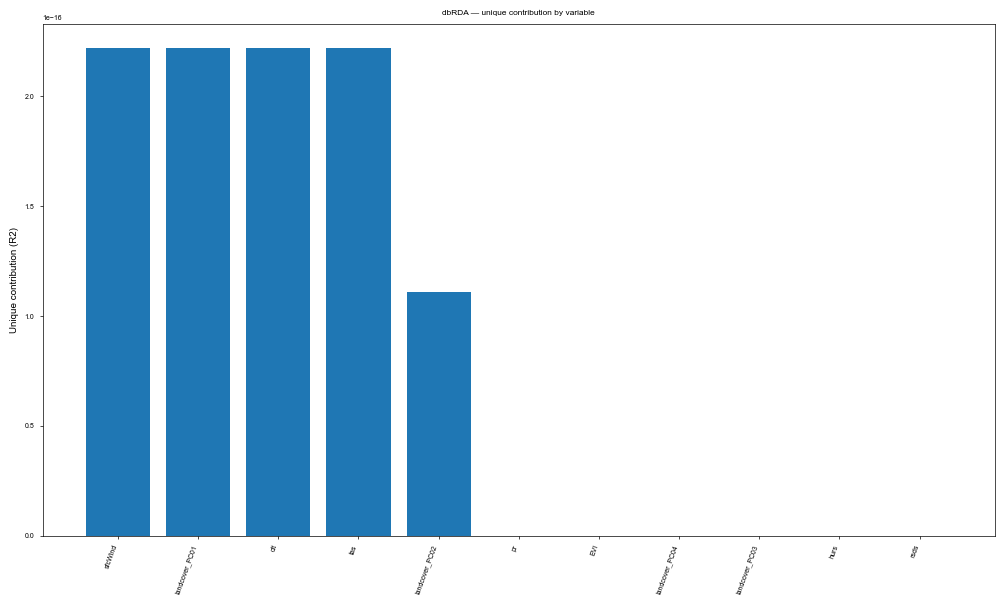

Saved: plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/dbrda_unique_bar.png


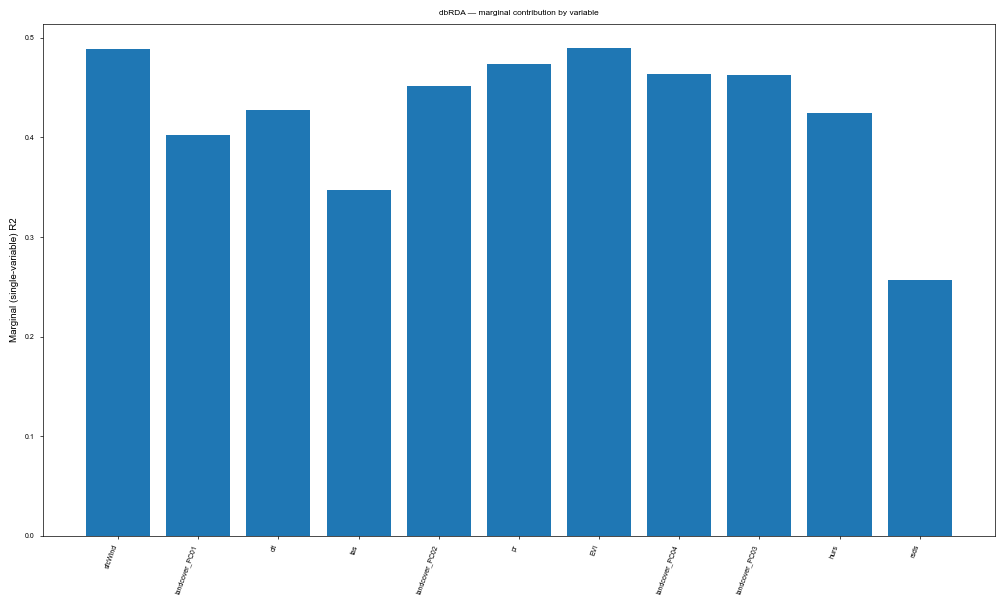

Saved: plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/dbrda_marginal_bar.png


In [207]:
# Cell 7 — 視覺化：變數重要性（唯一貢獻 R2_unique 與邊際 R2_marg）
res_plot = res.copy()
res_plot = res_plot.sort_values('R2_unique', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(res_plot['variable'], res_plot['R2_unique'])
plt.xticks(rotation=70, ha='right')
plt.ylabel('Unique contribution (R2)')
plt.title('dbRDA — unique contribution by variable')
plt.tight_layout()
bar1 = os.path.join(PU.plot_path_nichespace_clustering, 'dbrda_unique_bar.png')
plt.savefig(bar1, dpi=180)
plt.show()
print("Saved:", bar1)

plt.figure(figsize=(10,6))
plt.bar(res_plot['variable'], res_plot['R2_marg'])
plt.xticks(rotation=70, ha='right')
plt.ylabel('Marginal (single-variable) R2')
plt.title('dbRDA — marginal contribution by variable')
plt.tight_layout()
bar2 = os.path.join(PU.plot_path_nichespace_clustering, 'dbrda_marginal_bar.png')
plt.savefig(bar2, dpi=180)
plt.show()
print("Saved:", bar2)

## Add another dimension (attention score) to the PCA niche space (沒用到)
Test which direction represent the most variance

In [38]:
df = PU.df_nichespace_center_coordinate.join(PU.df_attention)

In [89]:
import numpy as np

def slope_direction(df, col='clt', xcol='PC01', ycol='PC02'):
    sub = df[[xcol, ycol, col]].dropna()
    x, y, z = sub[xcol].to_numpy(), sub[ycol].to_numpy(), sub[col].to_numpy()

    # 設計矩陣：Z = a*x + b*y + c
    X = np.column_stack([x, y, np.ones_like(x)])
    a, b, c = np.linalg.lstsq(X, z, rcond=None)[0]

    # 方向角與大小
    theta_rad = np.arctan2(b, a)
    theta_deg = np.degrees(theta_rad)           # 相對 x=PC01 軸，逆時針
    slope_mag = np.hypot(a, b)                  # 最大變化率（梯度長度）
    u = np.array([a, b]) / (slope_mag + 1e-12)  # 單位方向向量

    return {
        'a': a, 'b': b, 'c': c,
        'theta_deg': theta_deg,
        'slope_mag': slope_mag,
        'unit_vector': u
    }

res = slope_direction(df, col='clt', xcol='PC01', ycol='PC02')
print(res)


{'a': 0.0025079615427616732, 'b': -0.004072648781785107, 'c': 0.09278267521918114, 'theta_deg': -58.37498932700396, 'slope_mag': 0.004782921617562557, 'unit_vector': array([ 0.52435765, -0.85149812])}


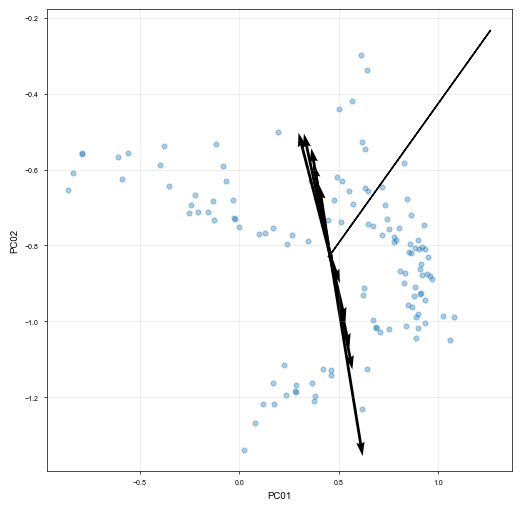

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 核心：計算各欄位的梯度（最陡上升方向） ----------
def gradients_for_columns(df, env_cols, xcol='PC01', ycol='PC02'):
    """
    回傳 dict: {col: {'a':a, 'b':b, 'c':c, 'mag':||∇||, 'theta_deg':θ, 'u':單位向量}}
    """
    out = {}
    for col in env_cols:
        sub = df[[xcol, ycol, col]].dropna()
        if sub.empty:
            continue
        x = sub[xcol].to_numpy()
        y = sub[ycol].to_numpy()
        z = sub[col].to_numpy()
        X = np.column_stack([x, y, np.ones_like(x)])
        a, b, c = np.linalg.lstsq(X, z, rcond=None)[0]
        mag = np.hypot(a, b)
        if mag == 0:
            u = np.array([0.0, 0.0])
        else:
            u = np.array([a, b]) / mag
        out[col] = {
            'a': a, 'b': b, 'c': c,
            'mag': mag,
            'theta_deg': np.degrees(np.arctan2(b, a)),
            'u': u
        }
    return out

# ---------- 視覺化：同圖畫出每個環境因子的方向箭頭 ----------
def plot_gradient_arrows(df, grads, xcol='PC01', ycol='PC02',
                         start='centroid', unit=False, scale=1.0,
                         show_points=True):
    """
    start: 'centroid'（重心）或 'origin'（原點）
    unit:  True → 只畫單位方向；False → 依梯度大小加權
    scale: 箭頭全域縮放係數（覺得太長/太短可調）
    """
    # 箭頭起點
    if start == 'origin':
        x0, y0 = 0.0, 0.0
    else:
        x0 = df[xcol].mean()
        y0 = df[ycol].mean()

    fig, ax = plt.subplots(figsize=(6, 6))

    # 背景散點（可關掉）
    if show_points:
        ax.scatter(df[xcol], df[ycol], s=12, alpha=0.35)

    # 箭頭
    handles = []
    labels  = []
    for col, g in grads.items():
        if g['mag'] == 0:
            continue
        vec = g['u'] if unit else np.array([g['a'], g['b']])  # 單位 or 真實梯度
        U, V = vec * scale
        q = ax.quiver([x0], [y0], [U], [V], angles='xy', scale_units='xy', scale=1, width=0.006)
        handles.append(q)
    ax.arrow(x0, y0, 0.804, 0.590)
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    # ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    ax.legend(handles, labels, loc='upper left')
    plt.show()

# ---------- 使用範例 ----------
# 1) 選環境欄位（排除座標與非環境欄）
env_cols = [c for c in df.columns if c not in ['PC01','PC02','cluster']]

# 或者只挑你要看的：
# env_cols = ['clt', 'hurs', 'pr', 'rsds', 'sfcWind', 'tas', 'EVI',
#             'landcover_PC01','landcover_PC02','landcover_PC03','landcover_PC04']

# 2) 計算梯度
grads = gradients_for_columns(df, env_cols, xcol='PC01', ycol='PC02')

# 3) 作圖
# 3a. 單位向量（只看方向）：unit=True；可把 scale 調到 0.5~2 方便觀察
plot_gradient_arrows(df, grads, unit=False, scale=6, start='centroid', show_points=True)

# 3b. 依梯度大小畫長短：unit=False（有時需要把 scale 調小，例如 0.2）
# plot_gradient_arrows(df, grads, unit=False, scale=0.3, start='centroid')
